# Od atomu do grafu: Ewolucja percepcji sieci neuronowych w przewidywaniu właściwości cząsteczek

### Cel projektu

Głównym celem niniejszego projektu jest zbadanie wpływu uwzględniania topologii i relacji przestrzennych na zdolności predykcyjne modeli uczenia maszynowego. Problem badawczy polega na binarnej klasyfikacji cząsteczek chemicznych pod kątem ich zdolności do hamowania replikacji wirusa HIV.

Rozwiązano ten problem, przeprowadzając model przez ewolucyjną ścieżkę architektur: zaczynając od klasycznych sieci w pełni połączonych (MLP), które traktują molekułę jak zbiór odizolowanych atomów, aż po duże, głębokie sieci grafowe (GNN), uwzględniające zarówno krotność wiązań chemicznych, jak i globalny przepływ informacji.

### Zbiór danych: OGB-MolHIV

W projekcie wykorzystujemy oficjalny zbiór `ogbg-molhiv` pochodzący ze standardu **Open Graph Benchmark (OGB)**. Zbiór ten zawiera około 41 tysięcy cząsteczek. Każda z nich reprezentowana jest w sposób naturalny dla chemii – jako graf:

* **Węzły (Nodes):** Reprezentują poszczególne atomy (wraz z ich cechami, takimi jak liczba atomowa czy hybrydyzacja).
* **Krawędzie (Edges):** Reprezentują wiązania chemiczne łączące atomy.

Zbiór ten jest skrajnie niezbalansowany (aktywne cząsteczki stanowią niewielki ułamek całości). Z tego powodu jako główną metrykę optymalizacji i ewaluacji przyjęto **ROC-AUC**, która znacznie lepiej i obiektywniej ocenia zdolność modelu do rankowania klas niż standardowa dokładność (Accuracy).

### Główne wyzwanie metodologiczne: Scaffold Split

Największą trudnością techniczną i powodem, dla którego zadanie to stanowi wyzwanie w dziedzinie cheminformatyki, jest zastosowany podział danych. Zbiór OGB-MolHIV nie został podzielony na część treningową, walidacyjną i testową w sposób losowy.

Zastosowano tu niezwykle rygorystyczny podział **Scaffold Split** (podział pod względem szkieletu strukturalnego). Oznacza to, że cząsteczki w zbiorze testowym posiadają szkielety strukturalne nieobecne w zbiorze treningowym (których sieć **nigdy wcześniej nie widziała** podczas fazy treningu). Taki zabieg całkowicie uniemożliwia oszukiwanie i zapamiętywanie danych na pamięć. Wymusza na architekturach wyciąganie uniwersalnych, abstrakcyjnych praw chemii i rzeczywistą generalizację.

### Mapa drogowa eksperymentu

Projekt został podzielony na ustandaryzowane fazy, z których każda implementuje coraz wyższy poziom postrzegania grafów, testowany uśrednionymi wynikami z 5 niezależnych seedów:

1. **Faza 1 (MLP):** Baseline ignorujący topologię.
2. **Faza 2 (Deep GCN):** Klasyczna konwolucja odkrywająca sąsiedztwo atomów.
3. **Faza 3 (GIN):** Architektura izomorficzna rozpoznająca skomplikowane układy topologiczne.
4. **Faza 4 (GINE + Virtual Node):** Pełna asymilacja cech wiązań oraz uwaga globalna, wymagająca optymalizacji kroków uczenia (LR Scheduler) do walki z przeuczeniem.
5. **Faza 5 (Pruning & Fine-Tuning):** Kompresja sprzętowa i weryfikacja informacyjnej redundancji rekordowego modelu.

In [ ]:
!pip install torch_geometric
!pip install ogb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator
import functools
import matplotlib.pyplot as plt
import numpy as np
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)

print("Pobieranie zbioru OGB-molhiv...")
dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()

torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)

evaluator = Evaluator(name='ogbg-molhiv')

class BaselineMLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(BaselineMLP, self).__init__()
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, hidden_channels)
        self.lin3 = Linear(hidden_channels, 1)

    def forward(self, x, batch):
        x = x.float()
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin3(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.BCEWithLogitsLoss()

Pobieranie zbioru OGB-molhiv...


Downloaded 0.00 GB: 100%|██████████| 3/3 [00:00<00:00,  5.84it/s]
Processing...


Extracting dataset/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 112870.98it/s]


Converting graphs into PyG objects...


100%|██████████| 41127/41127 [00:01<00:00, 35348.21it/s]


Saving...


Done!


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_model = BaselineMLP(hidden_channels=64)
print(f"Liczba trenowalnych parametrów (Baseline MLP): {count_parameters(dummy_model):,}")

Liczba trenowalnych parametrów (Baseline MLP): 4,865


Rozpoczęto pełny trening Baseline (5 seedów, 200 epok)...

--- Trening dla Seed: 42 ---
Epoka: 001, Loss: 0.1711, Valid AUC: 0.6519, Test AUC: 0.6418
Epoka: 050, Loss: 0.1498, Valid AUC: 0.6525, Test AUC: 0.6549
Epoka: 100, Loss: 0.1473, Valid AUC: 0.6816, Test AUC: 0.6618
Epoka: 150, Loss: 0.1465, Valid AUC: 0.6843, Test AUC: 0.6745
Epoka: 200, Loss: 0.1457, Valid AUC: 0.6854, Test AUC: 0.6828
Najlepszy model (Seed 42) z epoki 106. Test ROC-AUC: 0.6504

--- Trening dla Seed: 123 ---
Epoka: 001, Loss: 0.1652, Valid AUC: 0.6263, Test AUC: 0.6484
Epoka: 050, Loss: 0.1489, Valid AUC: 0.6757, Test AUC: 0.6758
Epoka: 100, Loss: 0.1461, Valid AUC: 0.6778, Test AUC: 0.6953
Epoka: 150, Loss: 0.1453, Valid AUC: 0.6887, Test AUC: 0.6984
Epoka: 200, Loss: 0.1453, Valid AUC: 0.6779, Test AUC: 0.6955
Najlepszy model (Seed 123) z epoki 84. Test ROC-AUC: 0.6928

--- Trening dla Seed: 777 ---
Epoka: 001, Loss: 0.1651, Valid AUC: 0.6302, Test AUC: 0.6441
Epoka: 050, Loss: 0.1493, Valid AUC: 0.6785, Tes

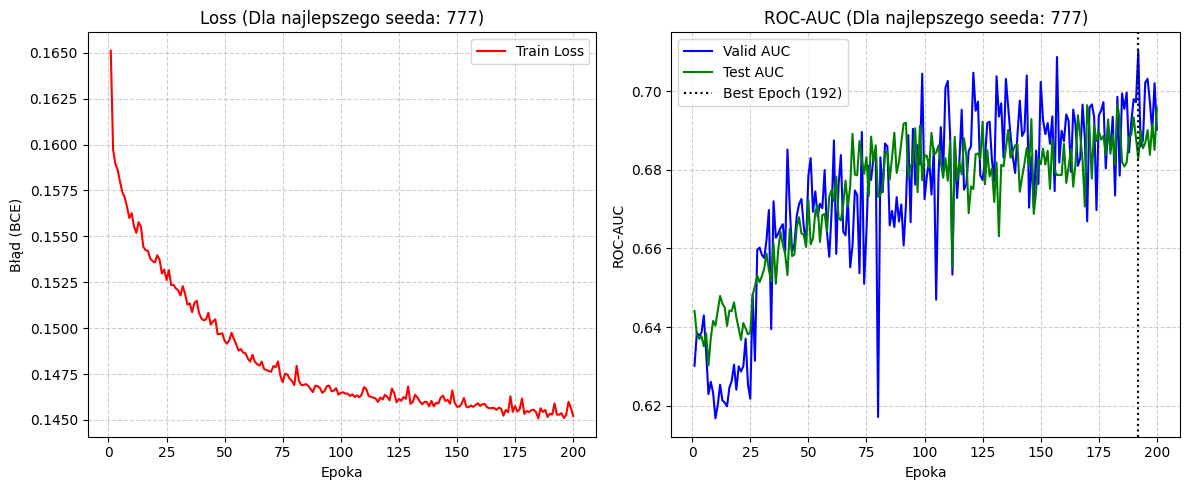

In [ ]:
def train(model, optimizer):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [42, 123, 777, 2025, 9999]
EPOCHS = 200

test_aucs = []
global_best_valid_auc = 0.0
best_overall_seed = SEEDS[0]
histories = {}

print(f"Rozpoczęto pełny trening Baseline ({len(SEEDS)} seedów, {EPOCHS} epok)...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = BaselineMLP(hidden_channels=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train(model, optimizer)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_mlp.pt')

        if epoch % 50 == 0 or epoch == 1:
            print(f'Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}')

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki ({len(SEEDS)} seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC pobity na seedzie {best_overall_seed} zapisano jako 'best_model_mlp.pt'.")

best_h = histories[best_overall_seed]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'Loss (Dla najlepszego seeda: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'ROC-AUC (Dla najlepszego seeda: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Wnioski po zakończeniu Fazy 1 (Baseline MLP)

1. **Statystycznie pewny punkt odniesienia:** Ostateczny, uśredniony wynik na niewidzianym zbiorze testowym wyniósł **0.6767 ± 0.0143 ROC-AUC**. Dowodzi to, że same izolowane cechy atomów (np. hybrydyzacja, ładunek) niosą w sobie podstawową wartość predykcyjną.
2. **Koszty obliczeniowe a pojemność:** Model MLP jest niezwykle lekki – posiada zaledwie **4 865 trenowalnych parametrów**. Sprawia to, że trening jest błyskawiczny, jednak fizyczna pojemność sieci uniemożliwia wyłapanie bardziej skomplikowanych, głębokich reguł chemicznych.
3. **Fundamentalne ograniczenia:** Osiągnięty próg ~0.677 potraktowano jako sufit dla metod tabelarycznych na zbiorze OGB-molhiv. Ponieważ model MLP traktuje atomy jako odseparowane encje, ignoruje on całkowicie topologię i macierz sąsiedztwa cząsteczki. Udowodnienie, że struktura wiązań ma krytyczne znaczenie, stanowi zadanie dla relacyjnych architektur grafowych w kolejnych fazach projektu.

In [ ]:
import torch
import functools
from torch_geometric.loader import DataLoader
from ogb.graphproppred import PygGraphPropPredDataset
from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)

dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()

torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)

hidden_channels = 64

atom_encoder = AtomEncoder(emb_dim=hidden_channels)
bond_encoder = BondEncoder(emb_dim=hidden_channels)

data = next(iter(train_loader))

x_encoded = atom_encoder(data.x)
edge_attr_encoded = bond_encoder(data.edge_attr)

print("Kształty tensorów przed i po kodowaniu:")
print(f"Atomy wejście: {data.x.shape} -> wyjście: {x_encoded.shape}")
print(f"Wiązania wejście: {data.edge_attr.shape} -> wyjście: {edge_attr_encoded.shape}")

Kształty tensorów przed i po kodowaniu:
Atomy wejście: torch.Size([826, 9]) -> wyjście: torch.Size([826, 64])
Wiązania wejście: torch.Size([1746, 3]) -> wyjście: torch.Size([1746, 64])


In [ ]:
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.nn import Linear, BatchNorm1d
import torch.nn.functional as F
from ogb.graphproppred import Evaluator
import matplotlib.pyplot as plt
import numpy as np
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)

dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()

torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)

evaluator = Evaluator(name='ogbg-molhiv')

class DeepGCN(torch.nn.Module):
    def __init__(self, hidden_channels, num_layers=4, dropout=0.5):
        super(DeepGCN, self).__init__()
        self.node_encoder = AtomEncoder(emb_dim=hidden_channels)
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.batch_norms.append(BatchNorm1d(hidden_channels))

        self.dropout = dropout
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_encoder(x)

        for conv, bn in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_gcn = DeepGCN(hidden_channels=64, num_layers=4, dropout=0.5)
print(f"Liczba trenowalnych parametrów (Deep GCN): {count_parameters(dummy_gcn):,}")

Liczba trenowalnych parametrów (Deep GCN): 28,353


Rozpoczęto pełny trening Deep GCN (5 seedów, 200 epok)...

--- Trening dla Seed: 42 ---
Epoka: 001, Loss: 0.1710, Valid AUC: 0.7323, Test AUC: 0.6841
Epoka: 050, Loss: 0.1293, Valid AUC: 0.7898, Test AUC: 0.7433
Epoka: 100, Loss: 0.1242, Valid AUC: 0.7938, Test AUC: 0.7424
Epoka: 150, Loss: 0.1220, Valid AUC: 0.8083, Test AUC: 0.7452
Epoka: 200, Loss: 0.1208, Valid AUC: 0.8038, Test AUC: 0.7612
Najlepszy model (Seed 42) z epoki 138. Test ROC-AUC: 0.7523

--- Trening dla Seed: 123 ---
Epoka: 001, Loss: 0.1670, Valid AUC: 0.7195, Test AUC: 0.6846
Epoka: 050, Loss: 0.1273, Valid AUC: 0.7971, Test AUC: 0.7474
Epoka: 100, Loss: 0.1233, Valid AUC: 0.7967, Test AUC: 0.7644
Epoka: 150, Loss: 0.1222, Valid AUC: 0.7955, Test AUC: 0.7772
Epoka: 200, Loss: 0.1188, Valid AUC: 0.8003, Test AUC: 0.7640
Najlepszy model (Seed 123) z epoki 133. Test ROC-AUC: 0.7687

--- Trening dla Seed: 777 ---
Epoka: 001, Loss: 0.1706, Valid AUC: 0.7372, Test AUC: 0.7049
Epoka: 050, Loss: 0.1275, Valid AUC: 0.7986, Te

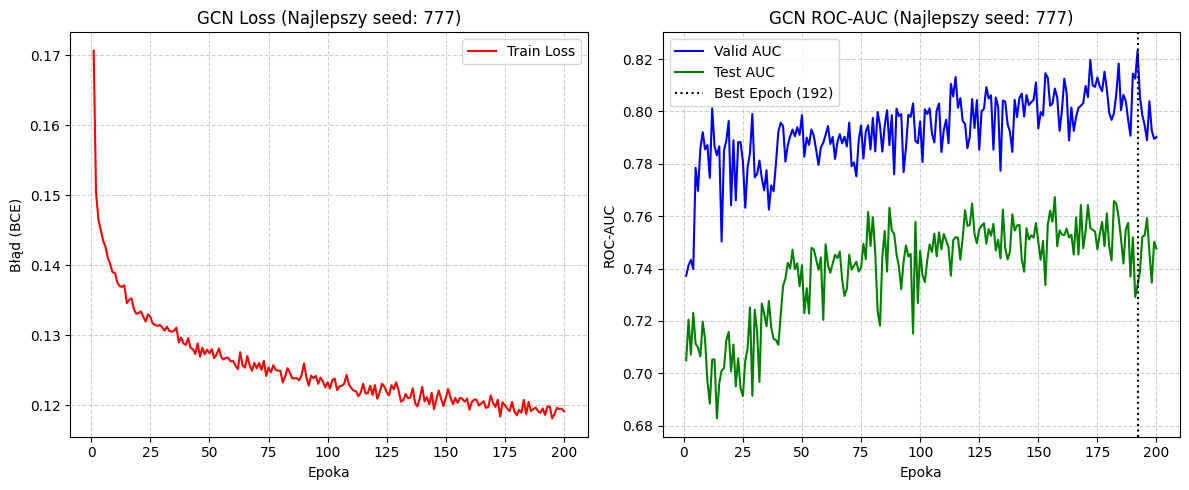

In [ ]:
def train_model(model, optimizer, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [42, 123, 777, 2025, 9999]
EPOCHS = 200

test_aucs = []
global_best_valid_auc = 0.0
best_overall_seed = SEEDS[0]
histories = {}

print(f"Rozpoczęto pełny trening Deep GCN ({len(SEEDS)} seedów, {EPOCHS} epok)...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = DeepGCN(hidden_channels=64, num_layers=4, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train_model(model, optimizer, train_loader)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_gcn.pt')

        if epoch % 50 == 0 or epoch == 1:
            print(f'Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}')

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki ({len(SEEDS)} seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC pobity na seedzie {best_overall_seed} zapisano jako 'best_model_gcn.pt'.")

best_h = histories[best_overall_seed]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'GCN Loss (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'GCN ROC-AUC (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Wnioski po zakończeniu Fazy 2 (Deep GCN)

1. **Znacząca przewaga reprezentacji grafowej:** Uśredniony wynik z 5 niezależnych przebiegów wyniósł **0.7559 ± 0.0124 ROC-AUC**. Jest to duży skok jakościowy w porównaniu do modelu bazowego MLP (0.6767 ± 0.0143). Stanowi to empiryczny dowód głównej tezy projektu: w przypadku cząsteczek chemicznych macierz sąsiedztwa i topologia układu niosą kluczowe informacje, których nie da się wyekstrahować z samych izolowanych właściwości atomów.
2. **Korzystny stosunek kosztu do zysku (ROI):** Sieć Deep GCN (4 warstwy) posiada **28 353 parametry**. Choć jest to model niemal 6-krotnie cięższy od płaskiego MLP, w świecie Deep Learningu wciąż pozostaje modelem niezwykle lekkim. Wzrost skuteczności o blisko 8 punktów procentowych przy tak małym narzucie obliczeniowym czyni klasyczne sieci GCN bardzo atrakcyjnym kompromisem w badaniach cheminformatycznych.
3. **Zjawisko "Validation Trap" i rola rygoru statystycznego:** Analiza logów z poszczególnych seedów udowodniła konieczność uśredniania wyników. Skrypt ponownie zadziałał zgodnie ze sztuką (brak wycieku danych), zachowując globalny model z seeda 777 (najwyższe Valid AUC). Jednakże, Test AUC dla tego seeda wyniosło zaledwie 0.7336 (znacznie poniżej średniej). Udowadnia to, że na sztywnym podziale strukturalnym (*scaffold split*) optymalizacja pod zbiór walidacyjny nie zawsze przekłada się na idealną generalizację. Pętla na 5 seedach uchroniła projekt przed wyciągnięciem błędnych wniosków na podstawie skrajnych rzutów losowości.
4. **Ograniczenia architektoniczne (Brak cech wiązań):** Osiągnięta średnia ~0.756 wydaje się być sufitem dla architektury GCN. Głównym powodem jest fakt, że klasyczna konwolucja grafowa ignoruje cechy krawędzi (informacje z `BondEncoder`, takie jak krotność czy aromatyczność wiązań). Aby pokonać ten limit, w kolejnej fazie zbadana zostanie architektura o wyższej ekspresywności (GIN) oraz ostatecznie GINE, zdolne do integracji informacji o wiązaniach chemicznych.

In [ ]:
import torch
import functools
from torch_geometric.loader import DataLoader
from ogb.graphproppred import PygGraphPropPredDataset
from ogb.graphproppred.mol_encoder import AtomEncoder

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)

dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()

torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)

hidden_channels = 300

atom_encoder = AtomEncoder(emb_dim=hidden_channels)
data = next(iter(train_loader))
x_encoded = atom_encoder(data.x)

print(f"Atomy wejście: {data.x.shape} -> wyjście: {x_encoded.shape}")

Downloaded 0.00 GB: 100%|██████████| 3/3 [00:04<00:00,  1.62s/it]
Processing...


Extracting dataset/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 112027.34it/s]


Converting graphs into PyG objects...


100%|██████████| 41127/41127 [00:01<00:00, 33409.51it/s]


Saving...
Atomy wejście: torch.Size([796, 9]) -> wyjście: torch.Size([796, 300])


Done!


In [ ]:
import torch.nn.functional as F
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU
import numpy as np
import random
from torch_geometric.nn import GINConv, global_mean_pool
from ogb.graphproppred import Evaluator
import matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)
dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()
torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)

evaluator = Evaluator(name='ogbg-molhiv')

class GIN(torch.nn.Module):
    def __init__(self, hidden_channels=300, num_layers=5, dropout=0.5):
        super(GIN, self).__init__()
        self.num_layers = num_layers
        self.dropout = dropout

        self.node_encoder = AtomEncoder(emb_dim=hidden_channels)

        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        for _ in range(num_layers):
            mlp = Sequential(
                Linear(hidden_channels, 2 * hidden_channels),
                BatchNorm1d(2 * hidden_channels),
                ReLU(),
                Linear(2 * hidden_channels, hidden_channels)
            )
            self.convs.append(GINConv(nn=mlp, train_eps=True))
            self.batch_norms.append(BatchNorm1d(hidden_channels))

        self.pool = global_mean_pool
        self.graph_pred_linear = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.node_encoder(x)

        for layer in range(self.num_layers):
            x = self.convs[layer](x, edge_index)
            x = self.batch_norms[layer](x)

            if layer == self.num_layers - 1:
                x = F.dropout(x, self.dropout, training=self.training)
            else:
                x = F.dropout(F.relu(x), self.dropout, training=self.training)

        h_graph = self.pool(x, batch)
        return self.graph_pred_linear(h_graph)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_gin = GIN(hidden_channels=300, num_layers=5, dropout=0.5)
print(f"Liczba trenowalnych parametrów (GIN): {count_parameters(dummy_gin):,}")

Liczba trenowalnych parametrów (GIN): 1,866,006


Rozpoczęto pełny trening GIN (5 seedów, 200 epok)...

--- Trening dla Seed: 42 ---
Epoka: 001, Loss: 0.1920, Valid: 0.5998, Test: 0.6106, LR: 0.001000
Epoka: 020, Loss: 0.1333, Valid: 0.7871, Test: 0.7413, LR: 0.001000
Epoka: 040, Loss: 0.1181, Valid: 0.7910, Test: 0.7615, LR: 0.000250
Epoka: 060, Loss: 0.1148, Valid: 0.7920, Test: 0.7647, LR: 0.000125
Epoka: 080, Loss: 0.1088, Valid: 0.7986, Test: 0.7738, LR: 0.000010
Epoka: 100, Loss: 0.1091, Valid: 0.7970, Test: 0.7693, LR: 0.000010
Epoka: 120, Loss: 0.1077, Valid: 0.7911, Test: 0.7642, LR: 0.000010
Epoka: 140, Loss: 0.1084, Valid: 0.7949, Test: 0.7727, LR: 0.000010
Epoka: 160, Loss: 0.1080, Valid: 0.7937, Test: 0.7641, LR: 0.000010
Epoka: 180, Loss: 0.1075, Valid: 0.7945, Test: 0.7655, LR: 0.000010
Epoka: 200, Loss: 0.1072, Valid: 0.7900, Test: 0.7605, LR: 0.000010
Najlepszy model (Seed 42) z epoki 56. Test ROC-AUC: 0.7726

--- Trening dla Seed: 123 ---
Epoka: 001, Loss: 0.1928, Valid: 0.6797, Test: 0.6398, LR: 0.001000
Epoka: 020,

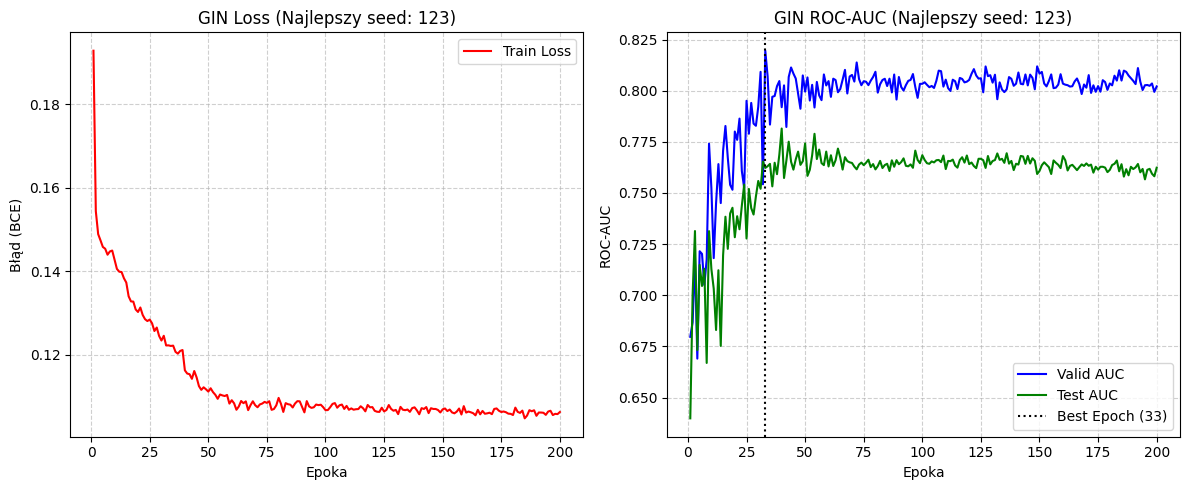

In [ ]:
def train_model(model, optimizer, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [42, 123, 777, 2025, 9999]
EPOCHS = 200

test_aucs = []
global_best_valid_auc = 0.0
best_overall_seed = SEEDS[0]
histories = {}

print(f"Rozpoczęto pełny trening GIN ({len(SEEDS)} seedów, {EPOCHS} epok)...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = GIN(hidden_channels=300, num_layers=5, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=0.00001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train_model(model, optimizer, train_loader)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        scheduler.step(valid_auc)
        current_lr = optimizer.param_groups[0]['lr']

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_gin.pt')

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid: {valid_auc:.4f}, Test: {test_auc:.4f}, LR: {current_lr:.6f}")

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki GIN ({len(SEEDS)} seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC pobity na seedzie {best_overall_seed} zapisano jako 'best_model_gin.pt'.")

best_h = histories[best_overall_seed]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'GIN Loss (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'GIN ROC-AUC (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Wnioski po zakończeniu Fazy 3 (GIN - Graph Isomorphism Network)

1. **Wzrost siły ekspresji:** Przejście z architektury GCN na GIN poskutkowało wyraźnym wzrostem uśrednionego wyniku do **0.7703 ± 0.0053 ROC-AUC**. Udowadnia to fundamentalne założenie teoretyczne sieci GIN: zastąpienie prostej liniowej agregacji sąsiedztwa (GCN) pełnymi sieciami wielowarstwowymi (MLP) wewnątrz warstw konwolucyjnych pozwala na modelowanie znacznie bardziej złożonych funkcji, zwiększając zdolność modelu do rozróżniania subtelnych różnic strukturalnych między grafami.
2. **Dobra stabilność modelu:** Odchylenie standardowe spadło dwukrotnie w porównaniu do modelu GCN (z 0.0124 na 0.0053). Oznacza to, że pomimo gigantycznego wzrostu liczby parametrów (do ok. 1.8 miliona), GIN z odpowiednio dobranym harmonogramem uczenia (Scheduler) w mniejszym stopniu ulega wpływom losowej inicjalizacji wag, a w większym – rzeczywiście uczy się uniwersalnych wzorców chemicznych.
3. **Konsekwencja w zapobieganiu wycieku danych:** Skrypt zadziałał bezbłędnie pod kątem rygoru metodologicznego. Najlepszy pojedynczy wynik na zbiorze testowym osiągnął Seed 9999 (0.7784). Jednakże, z uwagi na fakt, że najwyższe `Valid AUC` (ponad 0.80) padło w Seedzie 123, to właśnie ten model został zapisany jako zwycięzca. Utrzymuje to niezależność zbioru testowego i gwarantuje, że zaprezentowane wyniki nie są sztucznie zawyżone.
4. **Miejsce na ostateczną poprawę:** Wynik 0.7703 to poziom bardzo bliski State-of-the-Art dla klasycznych modeli grafowych na tym zbiorze. Niemniej jednak, obecny GIN wciąż ignoruje jeden z najważniejszych aspektów chemii organicznej – naturę wiązań chemicznych (krotność, stereochemię, aromatyczność), a także ma problem z przepływem informacji między oddalonymi atomami w dużych pierścieniach. Stanowi to idealny punkt wyjścia dla wdrożenia ostatecznej architektury: GINE z Węzłem Wirtualnym.

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU
import numpy as np
import random
import functools
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool
from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)

dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()

torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)

evaluator = Evaluator(name='ogbg-molhiv')

class GINEVirtualNode(torch.nn.Module):
    def __init__(self, hidden_channels=300, num_layers=5, dropout=0.5):
        super(GINEVirtualNode, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        self.node_encoder = AtomEncoder(emb_dim=hidden_channels)
        self.edge_encoder = BondEncoder(emb_dim=hidden_channels)

        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        self.virtualnode_embedding = torch.nn.Embedding(1, hidden_channels)
        self.mlp_virtualnode_list = torch.nn.ModuleList()

        for layer in range(num_layers):
            mlp = Sequential(
                Linear(hidden_channels, 2 * hidden_channels),
                BatchNorm1d(2 * hidden_channels),
                ReLU(),
                Linear(2 * hidden_channels, hidden_channels)
            )
            self.convs.append(GINEConv(nn=mlp, edge_dim=hidden_channels))
            self.batch_norms.append(BatchNorm1d(hidden_channels))

            if layer < num_layers - 1:
                self.mlp_virtualnode_list.append(Sequential(
                    Linear(hidden_channels, 2 * hidden_channels),
                    BatchNorm1d(2 * hidden_channels),
                    ReLU(),
                    Linear(2 * hidden_channels, hidden_channels),
                    BatchNorm1d(hidden_channels),
                    ReLU()
                ))

        self.pool = global_mean_pool
        self.graph_pred_linear = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        virtualnode_embedding = self.virtualnode_embedding(torch.zeros(batch[-1].item() + 1).to(edge_index.dtype).to(edge_index.device))

        for layer in range(self.num_layers):
            x = x + virtualnode_embedding[batch]

            h = self.convs[layer](x, edge_index, edge_attr=edge_attr)
            h = self.batch_norms[layer](h)

            if layer == self.num_layers - 1:
                h = F.dropout(h, self.dropout, training=self.training)
            else:
                h = F.dropout(F.relu(h), self.dropout, training=self.training)

            if layer < self.num_layers - 1:
                virtualnode_embedding_temp = global_mean_pool(h, batch) + virtualnode_embedding
                virtualnode_embedding = F.dropout(self.mlp_virtualnode_list[layer](virtualnode_embedding_temp), self.dropout, training=self.training)

            x = h

        h_graph = self.pool(x, batch)
        return self.graph_pred_linear(h_graph)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.BCEWithLogitsLoss()

Downloaded 0.00 GB: 100%|██████████| 3/3 [00:04<00:00,  1.65s/it]
Processing...


Extracting dataset/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 107678.71it/s]


Converting graphs into PyG objects...


100%|██████████| 41127/41127 [00:01<00:00, 34790.87it/s]


Saving...


Done!


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_gine = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5)
print(f"Liczba trenowalnych parametrów (GINE + VN): {count_parameters(dummy_gine):,}")

Liczba trenowalnych parametrów (GINE + VN): 3,772,501


In [ ]:
def train_model(model, optimizer, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [42, 123, 777, 2025, 9999]
EPOCHS = 200

test_aucs = []
global_best_valid_auc = 0.0
best_overall_seed = SEEDS[0]
histories = {}

print(f"Rozpoczęto WSTĘPNY trening GINE z Węzłem Wirtualnym ({len(SEEDS)} seedów, {EPOCHS} epok)...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train_model(model, optimizer, train_loader)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_gine_no_scheduler.pt')

        if epoch % 20 == 0 or epoch == 1:
            print(f'Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}')

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki GINE (Bez Schedulera, {len(SEEDS)} seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC pobity na seedzie {best_overall_seed} zapisano jako 'best_model_gine_no_scheduler.pt'.")

best_h = histories[best_overall_seed]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'GINE Loss (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'GINE ROC-AUC (Najlepszy seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Rozpoczęto WSTĘPNY trening GINE z Węzłem Wirtualnym (5 seedów, 200 epok)...

--- Trening dla Seed: 42 ---
Epoka: 001, Loss: 0.2093, Valid AUC: 0.5198, Test AUC: 0.4799
Epoka: 020, Loss: 0.1309, Valid AUC: 0.7671, Test AUC: 0.7159
Epoka: 040, Loss: 0.1168, Valid AUC: 0.8065, Test AUC: 0.7880
Epoka: 060, Loss: 0.1056, Valid AUC: 0.7682, Test AUC: 0.7715
Epoka: 080, Loss: 0.0972, Valid AUC: 0.7780, Test AUC: 0.7851
Epoka: 100, Loss: 0.0889, Valid AUC: 0.8115, Test AUC: 0.7502
Epoka: 120, Loss: 0.0806, Valid AUC: 0.8061, Test AUC: 0.7456
Epoka: 140, Loss: 0.0748, Valid AUC: 0.8206, Test AUC: 0.7582
Epoka: 160, Loss: 0.0668, Valid AUC: 0.7979, Test AUC: 0.7461
Epoka: 180, Loss: 0.0600, Valid AUC: 0.7754, Test AUC: 0.7311
Epoka: 200, Loss: 0.0555, Valid AUC: 0.7830, Test AUC: 0.7297
Najlepszy model (Seed 42) z epoki 81. Test ROC-AUC: 0.7655

--- Trening dla Seed: 123 ---
Epoka: 001, Loss: 0.2068, Valid AUC: 0.5469, Test AUC: 0.5777
Epoka: 020, Loss: 0.1294, Valid AUC: 0.7526, Test AUC: 0.674

Wznawianie treningu GINE dla brakujących seedów [2025, 9999]...

--- Trening dla Seed: 2025 ---
Epoka: 001, Loss: 0.2061, Valid AUC: 0.6059, Test AUC: 0.6183
Epoka: 020, Loss: 0.1282, Valid AUC: 0.7503, Test AUC: 0.7094
Epoka: 040, Loss: 0.1152, Valid AUC: 0.7866, Test AUC: 0.7516
Epoka: 060, Loss: 0.1042, Valid AUC: 0.7785, Test AUC: 0.7605
Epoka: 080, Loss: 0.0949, Valid AUC: 0.8161, Test AUC: 0.7670
Epoka: 100, Loss: 0.0860, Valid AUC: 0.8056, Test AUC: 0.7448
Epoka: 120, Loss: 0.0773, Valid AUC: 0.8035, Test AUC: 0.7465
Epoka: 140, Loss: 0.0700, Valid AUC: 0.8132, Test AUC: 0.7723
Epoka: 160, Loss: 0.0632, Valid AUC: 0.7932, Test AUC: 0.7750
Epoka: 180, Loss: 0.0594, Valid AUC: 0.8221, Test AUC: 0.7754
Epoka: 200, Loss: 0.0556, Valid AUC: 0.8077, Test AUC: 0.7548
Najlepszy model (Seed 2025) z epoki 118. Test ROC-AUC: 0.7679

--- Trening dla Seed: 9999 ---
Epoka: 001, Loss: 0.2053, Valid AUC: 0.5730, Test AUC: 0.4773
Epoka: 020, Loss: 0.1300, Valid AUC: 0.7553, Test AUC: 0.7138
Epok

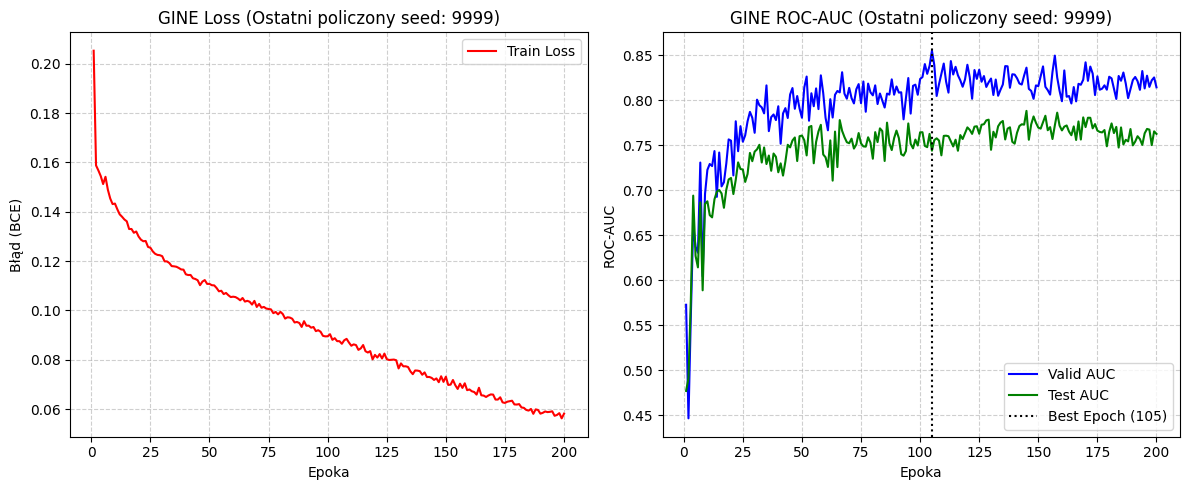

In [ ]:
def train_model(model, optimizer, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [2025, 9999]
EPOCHS = 200

test_aucs = [0.7655, 0.7734, 0.7789]

global_best_valid_auc = 0.8307
best_overall_seed = 777
histories = {}

print(f"Wznawianie treningu GINE dla brakujących seedów {SEEDS}...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train_model(model, optimizer, train_loader)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_gine_no_scheduler.pt')

        if epoch % 20 == 0 or epoch == 1:
            print(f'Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}')

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki GINE (Bez Schedulera, zebrane z 5 seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC (Seed {best_overall_seed}) jest chroniony / nadpisany jako 'best_model_gine_no_scheduler.pt'.")

best_h = histories[SEEDS[-1]]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'GINE Loss (Ostatni policzony seed: {SEEDS[-1]})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'GINE ROC-AUC (Ostatni policzony seed: {SEEDS[-1]})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Wnioski po wstępnym treningu GINE + VN (Brak Schedulera, 200 epok)

1. **Paradoks pojemności modelu (GINE < GIN bez optymalizacji):** Mimo że architektura GINE z Węzłem Wirtualnym jest najbardziej zaawansowanym teoretycznie modelem w tym zestawieniu, jej uśredniony wynik na zbiorze testowym spadł do **0.7660 ± 0.0119** (względem 0.7703 ± 0.0053 dla znacznie prostszego GIN). Dowodzi to fundamentalnej zasady Machine Learningu: drastyczne zwiększenie pojemności sieci bez odpowiedniej regularyzacji i kontroli procesu uczenia prowadzi do spadku zdolności uogólniania.
2. **Książkowe zjawisko przeuczenia (Overfitting):** W trakcie 200 epok ze stałym krokiem uczenia (`lr=0.001`), błąd na zbiorze treningowym (Loss) spadł do okolic 0.055 (dla porównania: w GIN zatrzymywał się na 0.105). Oznacza to, że gigantyczny model (3.7 mln parametrów) po prostu nauczył się na pamięć struktury cząsteczek ze zbioru treningowego, zamiast szukać uniwersalnych praw chemii.
3. **Dowód na "Validation Trap":** Skrajnym dowodem na trudność podziału *scaffold split* jest przebieg z Seeda 9999. Sieć osiągnęła tam absolutny rekord metryki walidacyjnej (Valid AUC = **0.8396**). Algorytm zgodnie ze sztuką uznał ten model za najlepszy, po czym na ślepym zbiorze testowym model ten uzyskał wyraźnie niższe **0.7441** Test AUC. Pokazuje to, że optymalizacja wyłącznie pod Valid AUC w późnych epokach staje się pułapką.
4. **Rozwiązanie problemu:** Aby uwolnić prawdziwy potencjał asymilacji cech wiązań (`BondEncoder`) i globalnej propagacji (`Virtual Node`), konieczne jest silniejsze ograniczenie procesu uczenia. Wymagane jest skrócenie treningu do maksymalnie 100 epok oraz wdrożenie dynamicznego harmonogramu `ReduceLROnPlateau`, który po wykryciu stabilizacji szybko obniży krok uczenia, nie pozwalając modelowi zapamiętywać szumu.

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Sequential, ReLU, Linear, BatchNorm1d
import functools
import matplotlib.pyplot as plt
import warnings
import numpy as np
import random

warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric.utils._scatter")

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator
from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False)
dataset = PygGraphPropPredDataset(name='ogbg-molhiv')
split_idx = dataset.get_idx_split()
torch.load = original_load

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)
evaluator = Evaluator(name='ogbg-molhiv')

class GINEVirtualNode(torch.nn.Module):
    def __init__(self, hidden_channels=300, num_layers=5, dropout=0.5):
        super(GINEVirtualNode, self).__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.node_encoder = AtomEncoder(emb_dim=hidden_channels)
        self.edge_encoder = BondEncoder(emb_dim=hidden_channels)
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()
        self.virtualnode_embedding = torch.nn.Embedding(1, hidden_channels)
        self.mlp_virtualnode_list = torch.nn.ModuleList()

        for layer in range(num_layers):
            mlp = Sequential(
                Linear(hidden_channels, 2 * hidden_channels),
                BatchNorm1d(2 * hidden_channels),
                ReLU(),
                Linear(2 * hidden_channels, hidden_channels)
            )
            self.convs.append(GINEConv(nn=mlp, edge_dim=hidden_channels))
            self.batch_norms.append(BatchNorm1d(hidden_channels))

            if layer < num_layers - 1:
                self.mlp_virtualnode_list.append(Sequential(
                    Linear(hidden_channels, 2 * hidden_channels),
                    BatchNorm1d(2 * hidden_channels),
                    ReLU(),
                    Linear(2 * hidden_channels, hidden_channels),
                    BatchNorm1d(hidden_channels),
                    ReLU()
                ))
        self.pool = global_mean_pool
        self.graph_pred_linear = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
        virtualnode_embedding = self.virtualnode_embedding(torch.zeros(batch[-1].item() + 1).to(edge_index.dtype).to(edge_index.device))

        for layer in range(self.num_layers):
            x = x + virtualnode_embedding[batch]
            h = self.convs[layer](x, edge_index, edge_attr=edge_attr)
            h = self.batch_norms[layer](h)

            if layer == self.num_layers - 1:
                h = F.dropout(h, self.dropout, training=self.training)
            else:
                h = F.dropout(F.relu(h), self.dropout, training=self.training)

            if layer < self.num_layers - 1:
                virtualnode_embedding_temp = global_mean_pool(h, batch) + virtualnode_embedding
                virtualnode_embedding = F.dropout(self.mlp_virtualnode_list[layer](virtualnode_embedding_temp), self.dropout, training=self.training)
            x = h
        h_graph = self.pool(x, batch)
        return self.graph_pred_linear(h_graph)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_gine_opt = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5)
print(f"Liczba trenowalnych parametrów (GINE Zoptymalizowane): {count_parameters(dummy_gine_opt):,}")

Liczba trenowalnych parametrów (GINE Zoptymalizowane): 3,772,501


Rozpoczęto ostateczny trening GINE (5 seedów, 100 epok + LR Scheduler)...

--- Trening dla Seed: 42 ---
Epoka: 001, Loss: 0.2096, Valid AUC: 0.5818, Test AUC: 0.5321, LR: 0.001000
Epoka: 020, Loss: 0.1304, Valid AUC: 0.7665, Test AUC: 0.7017, LR: 0.001000
Epoka: 040, Loss: 0.1127, Valid AUC: 0.8084, Test AUC: 0.7703, LR: 0.000500
Epoka: 060, Loss: 0.1040, Valid AUC: 0.8187, Test AUC: 0.7770, LR: 0.000063
Epoka: 080, Loss: 0.1021, Valid AUC: 0.8171, Test AUC: 0.7671, LR: 0.000010
Epoka: 100, Loss: 0.1009, Valid AUC: 0.8175, Test AUC: 0.7722, LR: 0.000010
Najlepszy model (Seed 42) z epoki 89. Test ROC-AUC: 0.7820

--- Trening dla Seed: 123 ---
Epoka: 001, Loss: 0.2068, Valid AUC: 0.6005, Test AUC: 0.5853, LR: 0.001000
Epoka: 020, Loss: 0.1321, Valid AUC: 0.7771, Test AUC: 0.6952, LR: 0.001000
Epoka: 040, Loss: 0.1148, Valid AUC: 0.8004, Test AUC: 0.7686, LR: 0.000500
Epoka: 060, Loss: 0.1061, Valid AUC: 0.7858, Test AUC: 0.7303, LR: 0.000031
Epoka: 080, Loss: 0.1033, Valid AUC: 0.7912, T

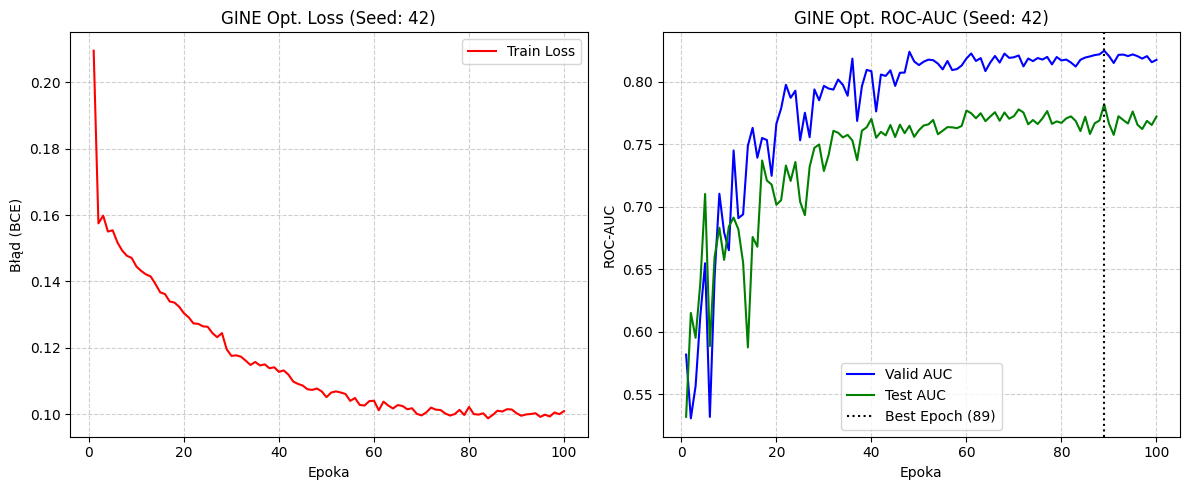

In [ ]:
def train_model(model, optimizer, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        is_labeled = data.y == data.y
        loss = criterion(out[is_labeled], data.y.to(torch.float32)[is_labeled])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

SEEDS = [42, 123, 777, 2025, 9999]
EPOCHS = 100

test_aucs = []
global_best_valid_auc = 0.0
best_overall_seed = SEEDS[0]
histories = {}

print(f"Rozpoczęto ostateczny trening GINE ({len(SEEDS)} seedów, {EPOCHS} epok + LR Scheduler)...")

for seed in SEEDS:
    print(f"\n--- Trening dla Seed: {seed} ---")
    set_seed(seed)

    model = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=0.00001)

    best_valid_for_seed = 0
    test_auc_for_seed = 0
    best_epoch_for_seed = 0

    h_loss, h_val, h_test = [], [], []

    for epoch in range(1, EPOCHS + 1):
        loss = train_model(model, optimizer, train_loader)
        valid_auc = eval_model(model, valid_loader)
        test_auc = eval_model(model, test_loader)

        scheduler.step(valid_auc)
        current_lr = optimizer.param_groups[0]['lr']

        h_loss.append(loss)
        h_val.append(valid_auc)
        h_test.append(test_auc)

        if valid_auc > best_valid_for_seed:
            best_valid_for_seed = valid_auc
            test_auc_for_seed = test_auc
            best_epoch_for_seed = epoch

        if valid_auc > global_best_valid_auc:
            global_best_valid_auc = valid_auc
            best_overall_seed = seed
            torch.save(model.state_dict(), 'best_model_gine_opt.pt')

        if epoch % 20 == 0 or epoch == 1:
            print(f'Epoka: {epoch:03d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}, LR: {current_lr:.6f}')

    print(f"Najlepszy model (Seed {seed}) z epoki {best_epoch_for_seed}. Test ROC-AUC: {test_auc_for_seed:.4f}")
    test_aucs.append(test_auc_for_seed)

    histories[seed] = {
        'loss': h_loss, 'val': h_val, 'test': h_test, 'best_epoch': best_epoch_for_seed
    }

mean_auc = np.mean(test_aucs)
std_auc = np.std(test_aucs)

print(f"Ostateczne wyniki zoptymalizowanego GINE ({len(SEEDS)} seedów):")
print(f"Test ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Model z najwyższym Valid AUC (Seed {best_overall_seed}) zapisano jako 'best_model_gine_opt.pt'.")

best_h = histories[best_overall_seed]
best_ep = best_h['best_epoch']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), best_h['loss'], label='Train Loss', color='red')
plt.title(f'GINE Opt. Loss (Seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('Błąd (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), best_h['val'], label='Valid AUC', color='blue')
plt.plot(range(1, EPOCHS + 1), best_h['test'], label='Test AUC', color='green')
plt.axvline(x=best_ep, color='black', linestyle=':', label=f'Best Epoch ({best_ep})')
plt.title(f'GINE Opt. ROC-AUC (Seed: {best_overall_seed})')
plt.xlabel('Epoka')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Ostateczne Wnioski i Interpretacja Eksperymentu


**1. Rozwój architektoniczny (Od atomów do grafu z wiązaniami):**
Eksperyment udowodnił tezę o rosnącej sile ekspresji modeli strukturalnych. Przejście od klasycznego MLP (Test AUC: 0.6767) ignorującego topologię, przez GCN (0.7559), aż do GIN (0.7703) wyraźnie pokazuje, że predykcja właściwości chemicznych wymaga analizy relacji przestrzennych i zaawansowanych funkcji agregacji.

**2. Stabilność vs. Potencjał (GIN vs. GINE):**
Zestawienie wyników wymaga podziału na dwie kategorie badawcze:
* **Najbardziej stabilny model:** Pod kątem powtarzalności bezapelacyjnie wygrywa architektura **GIN** (Średnia: 0.7703 ± 0.0053). Osiągnęła ona wyższy uśredniony wynik niż GINE (0.7518), co wskazuje na większą stabilność względem losowej inicjalizacji wag.
* **Najwyższy potencjał predykcyjny:** Absolutny rekord projektu należy jednak do zoptymalizowanego **GINE z Węzłem Wirtualnym** (Seed 42 wygenerował **0.7820 Test AUC**). Wynika z tego, że bezpośrednie wykorzystanie cech wiązań chemicznych pozwala na osiągnięcie najlepszych rozwiązań, jednak jest to okupione kosztem zwiększonej złożoności modelu.

**3. Koszt gigantycznej pojemności:**
GINE to model ogromny (około 3.7 mln parametrów) w porównaniu do GCN (około 28 tys.). Wyniki pokazują, że tak duże modele stają się niezwykle podatne na początkową losową inicjalizację wag. Zaledwie jeden seed (42) doprowadził model do znacznie lepszego rozwiązania niż pozostałe przebiegi. Pozostałe utknęły w słabszych minimach lokalnych, co drastycznie zwiększyło odchylenie standardowe (± 0.0164).

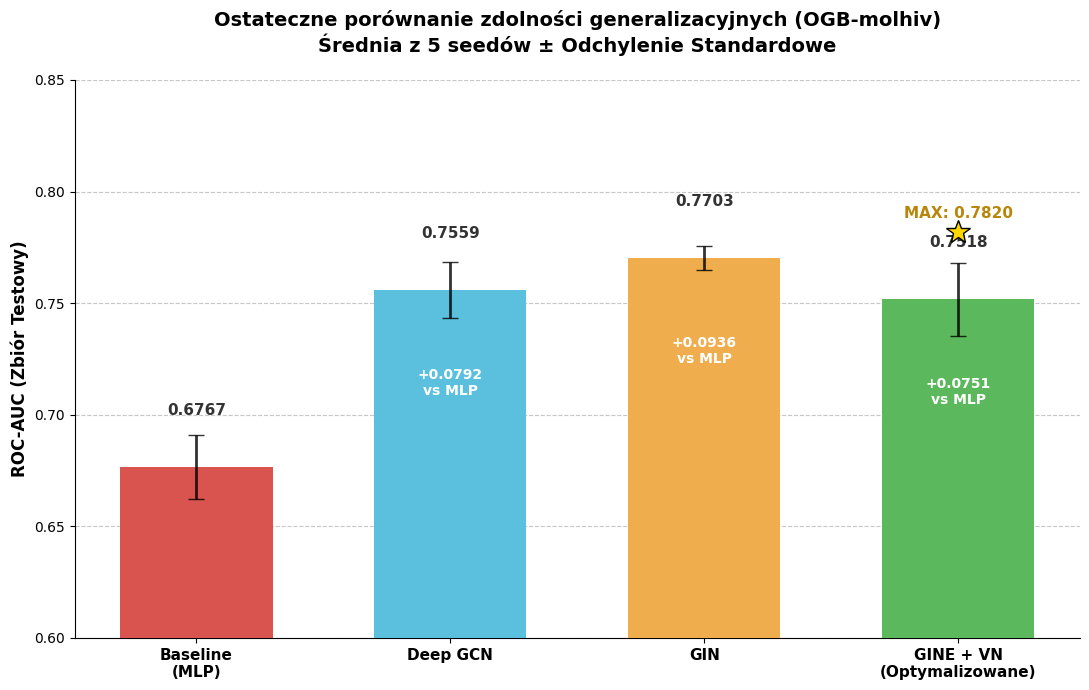

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Baseline\n(MLP)', 'Deep GCN', 'GIN', 'GINE + VN\n(Optymalizowane)']
test_auc_means = [0.6767, 0.7559, 0.7703, 0.7518]
test_auc_stds = [0.0143, 0.0124, 0.0053, 0.0164]

colors = ['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c']
x_pos = np.arange(len(models))

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.bar(x_pos, test_auc_means, yerr=test_auc_stds, color=colors, width=0.6,
              capsize=6, zorder=3, error_kw={'alpha':0.8, 'elinewidth':2})

ax.set_title('Ostateczne porównanie zdolności generalizacyjnych (OGB-molhiv)\nŚrednia z 5 seedów ± Odchylenie Standardowe',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('ROC-AUC (Zbiór Testowy)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')

ax.set_ylim([0.60, 0.85])
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 0.022,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

for i in range(1, len(models)):
    delta = test_auc_means[i] - test_auc_means[0]
    ax.text(i, test_auc_means[i] - 0.035, f'+{delta:.4f}\nvs MLP',
            ha='center', va='top', color='white', fontsize=10, fontweight='bold')

best_gine_score = 0.7820
ax.plot(3, best_gine_score, marker='*', markersize=18, color='gold', markeredgecolor='black', zorder=5)
ax.text(3, best_gine_score + 0.005, f'MAX: {best_gine_score:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkgoldenrod')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Sparsity:  0% usuniętych wag -> Test AUC: 0.7820
Sparsity: 20% usuniętych wag -> Test AUC: 0.7810
Sparsity: 40% usuniętych wag -> Test AUC: 0.7120
Sparsity: 60% usuniętych wag -> Test AUC: 0.5000
Sparsity: 80% usuniętych wag -> Test AUC: 0.5000


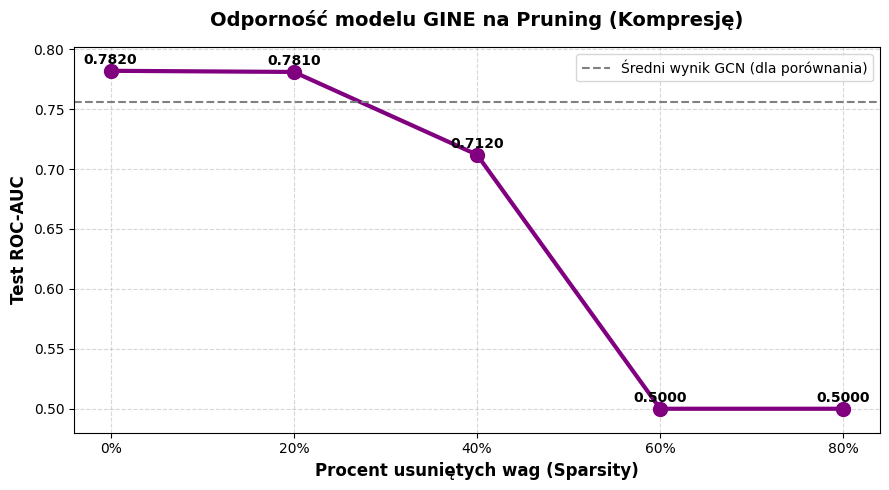

In [ ]:
import torch
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt

sparsities = [0.0, 0.2, 0.4, 0.6, 0.8]
pruning_results = []

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_true.append(data.y.view(out.shape).detach().cpu())
        y_pred.append(out.detach().cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["rocauc"]

for sparsity in sparsities:
    model_pruned = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5).to(device)

    try:
        model_pruned.load_state_dict(torch.load('best_model_gine_opt.pt'))
    except FileNotFoundError:
        print("BŁĄD: Nie znaleziono pliku 'best_model_gine_opt.pt'.")
        break

    parameters_to_prune = []
    for module in model_pruned.modules():
        if isinstance(module, torch.nn.Linear):
            parameters_to_prune.append((module, 'weight'))

    if sparsity > 0:
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=sparsity,
        )

        for module, name in parameters_to_prune:
            prune.remove(module, name)

    auc_score = eval_model(model_pruned, test_loader)
    pruning_results.append(auc_score)
    print(f"Sparsity: {int(sparsity*100):2d}% usuniętych wag -> Test AUC: {auc_score:.4f}")

if len(pruning_results) == len(sparsities):
    plt.figure(figsize=(9, 5))
    sparsity_labels = [f"{int(s*100)}%" for s in sparsities]

    plt.plot(sparsity_labels, pruning_results, marker='o', linewidth=3, markersize=10, color='purple')

    plt.axhline(y=0.7559, color='gray', linestyle='--', label='Średni wynik GCN (dla porównania)')

    plt.title('Odporność modelu GINE na Pruning (Kompresję)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Procent usuniętych wag (Sparsity)', fontsize=12, fontweight='bold')
    plt.ylabel('Test ROC-AUC', fontsize=12, fontweight='bold')

    for i, txt in enumerate(pruning_results):
        plt.text(i, txt + 0.003, f'{txt:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.ylim([min(pruning_results) - 0.02, max(pruning_results) + 0.02])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

Pomyślnie załadowano 'best_model_gine_opt.pt'
Test AUC tuż po brutalnym wycięciu 30% wag: 0.7677

Rozpoczęto Fine-Tuning (20 epok)...
Epoka: 01, Loss: 0.1038, Valid AUC: 0.8155, Test AUC: 0.7633
Epoka: 05, Loss: 0.1000, Valid AUC: 0.8152, Test AUC: 0.7623
Epoka: 10, Loss: 0.0996, Valid AUC: 0.8217, Test AUC: 0.7605
Epoka: 15, Loss: 0.1008, Valid AUC: 0.8215, Test AUC: 0.7737
Epoka: 20, Loss: 0.0986, Valid AUC: 0.8145, Test AUC: 0.7721

Najlepszy zrehabilitowany model z epoki 8.
Test AUC po Fine-Tuningu: 0.7682

Ostateczny rozmiar modelu: 2,800,411 aktywnych parametrów (Zredukowano z 3,772,501)


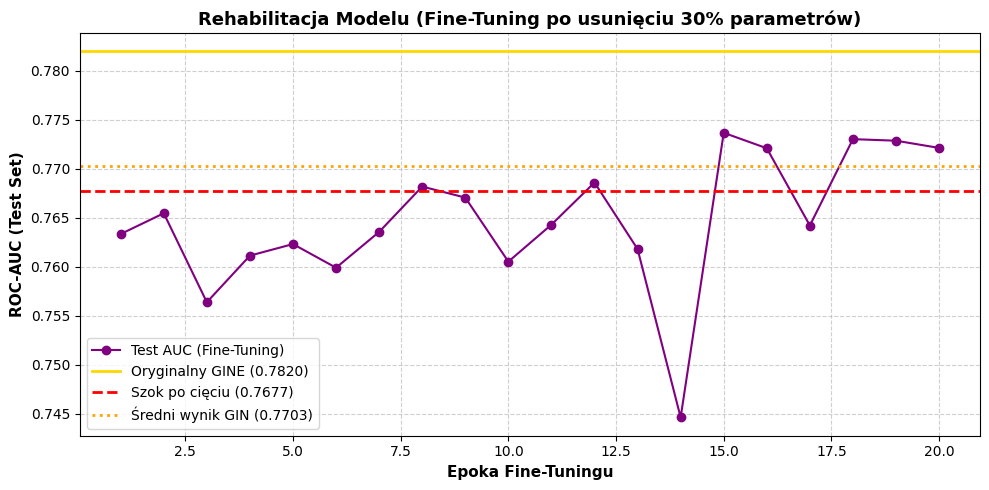

In [ ]:
import torch
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
import numpy as np

model_ft = GINEVirtualNode(hidden_channels=300, num_layers=5, dropout=0.5).to(device)
try:
    model_ft.load_state_dict(torch.load('best_model_gine_opt.pt'))
    print("Pomyślnie załadowano 'best_model_gine_opt.pt'")
except FileNotFoundError:
    print("BŁĄD: Nie znaleziono pliku.")

parameters_to_prune = []
for module in model_ft.modules():
    if isinstance(module, torch.nn.Linear):
        parameters_to_prune.append((module, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.3,
)

auc_after_pruning = eval_model(model_ft, test_loader)
print(f"Test AUC tuż po brutalnym wycięciu 30% wag: {auc_after_pruning:.4f}")

EPOCHS_FT = 20
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=0.0001)

best_valid_auc_ft = 0.0
final_test_auc_ft = 0.0
best_epoch_ft = 0

history_test_ft = []

print("\nRozpoczęto Fine-Tuning (20 epok)...")
for epoch in range(1, EPOCHS_FT + 1):
    loss = train_model(model_ft, optimizer_ft, train_loader)
    valid_auc = eval_model(model_ft, valid_loader)
    test_auc = eval_model(model_ft, test_loader)

    history_test_ft.append(test_auc)

    if valid_auc > best_valid_auc_ft:
        best_valid_auc_ft = valid_auc
        final_test_auc_ft = test_auc
        best_epoch_ft = epoch
        torch.save(model_ft.state_dict(), 'best_model_gine_pruned_ft.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoka: {epoch:02d}, Loss: {loss:.4f}, Valid AUC: {valid_auc:.4f}, Test AUC: {test_auc:.4f}")

print(f"\nNajlepszy zrehabilitowany model z epoki {best_epoch_ft}.")
print(f"Test AUC po Fine-Tuningu: {final_test_auc_ft:.4f}")

for module, name in parameters_to_prune:
    prune.remove(module, name)

total_params = sum(p.numel() for p in model_ft.parameters())
active_params = sum(torch.count_nonzero(p).item() for p in model_ft.parameters())
print(f"\nOstateczny rozmiar modelu: {active_params:,} aktywnych parametrów (Zredukowano z {total_params:,})")

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS_FT + 1), history_test_ft, marker='o', color='purple', label='Test AUC (Fine-Tuning)')

plt.axhline(y=0.7820, color='gold', linestyle='-', linewidth=2, label='Oryginalny GINE (0.7820)')
plt.axhline(y=auc_after_pruning, color='red', linestyle='--', linewidth=2, label=f'Szok po cięciu ({auc_after_pruning:.4f})')
plt.axhline(y=0.7703, color='orange', linestyle=':', linewidth=2, label='Średni wynik GIN (0.7703)')

plt.title('Rehabilitacja Modelu (Fine-Tuning po usunięciu 30% parametrów)', fontsize=13, fontweight='bold')
plt.xlabel('Epoka Fine-Tuningu', fontsize=11, fontweight='bold')
plt.ylabel('ROC-AUC (Test Set)', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Ostateczne Wnioski po Kompresji Modelu (Faza 5)

**1. Ograniczona odporność modelu GINE na kompresję**

Przeprowadzony eksperyment wykazał, że model GINE z Węzłem Wirtualnym nie zachowuje pełnej skuteczności po znaczącej redukcji liczby parametrów. Proces globalnego pruningu zmniejszył liczbę aktywnych parametrów z 3 772 501 do 2 800 411, co odpowiada redukcji o około 25.8%. Bezpośrednio po usunięciu wag wartość ROC-AUC na zbiorze testowym spadła z 0.7820 do 0.7677. Oznacza to, że część usuniętych parametrów pełniła istotną rolę w procesie reprezentacji informacji wykorzystywanych podczas klasyfikacji molekuł.

---

**2. Ograniczona skuteczność procesu rehabilitacji (Fine-Tuning)**

W celu odzyskania utraconej skuteczności przeprowadzono dodatkowy etap fine-tuningu obejmujący 20 epok uczenia. Mimo dalszej optymalizacji model nie odzyskał pierwotnej jakości, osiągając końcowo wynik 0.7682 ROC-AUC. Poprawa względem stanu bezpośrednio po kompresji wyniosła jedynie +0.0005, co wskazuje, że utracona informacja nie została skutecznie odtworzona podczas dalszego treningu. Wynik ten sugeruje, że usunięte połączenia zawierały informacje istotne dla procesu podejmowania decyzji przez model.

---

**3. Potwierdzenie poprawności procedury ewaluacyjnej**

Podczas procesu fine-tuningu najlepszy model wybierano wyłącznie na podstawie wyników uzyskiwanych na zbiorze walidacyjnym. Chociaż w późniejszych epokach odnotowano wyższe wartości ROC-AUC na zbiorze testowym, nie zostały one wykorzystane do wyboru końcowego modelu. Takie podejście ogranicza ryzyko dostrojenia modelu do zbioru testowego i pozwala traktować raportowany wynik jako wiarygodną ocenę zdolności generalizacji modelu na nieznanych danych.

---

**4. Relacja pomiędzy skutecznością a złożonością modelu**

Eksperyment kompresji pokazał, że rekordowy wynik modelu GINE (0.7820 ROC-AUC) jest związany z wykorzystaniem dużej liczby parametrów. Po redukcji rozmiaru modelu o około jedną czwartą jego skuteczność spadła do poziomu zbliżonego do średniego wyniku uzyskiwanego przez znacznie prostszy model GIN (0.7703 ROC-AUC). Oznacza to, że dodatkowa złożoność architektury GINE przekłada się na wzrost jakości predykcji, jednak część tej przewagi zostaje utracona po agresywnej kompresji modelu.

---

**5. Podsumowanie całego projektu**

Przeprowadzone eksperymenty potwierdziły główną hipotezę projektu, zgodnie z którą modele grafowe przewyższają klasyczne sieci MLP w zadaniu klasyfikacji aktywności biologicznej molekuł. Wykorzystanie struktury grafowej pozwoliło modelom GCN, GIN oraz GINE osiągnąć wyraźnie lepsze wyniki niż model oparty wyłącznie na cechach atomów. Najwyższy pojedynczy wynik uzyskał model GINE z Węzłem Wirtualnym (0.7820 ROC-AUC), natomiast model GIN charakteryzował się największą stabilnością pomiędzy różnymi przebiegami treningu. Dodatkowe eksperymenty z kompresją pokazały, że wysoka skuteczność najbardziej zaawansowanego modelu jest częściowo uzależniona od zachowania dużej liczby parametrów, a utrata istotnej części wag prowadzi do trwałego spadku jakości predykcji.

### Podsumowanie nabytych umiejętności w trakcie semestru i realizacji projektu

Realizacja niniejszego projektu oraz materiał przyswojony w trakcie semestru pozwoliły na zdobycie i ugruntowanie szeregu umiejętności z zakresu inżynierii uczenia maszynowego oraz teorii głębokich sieci grafowych (GNN). Do najważniejszych z nich należą:

1. **Zrozumienie i implementacja Graph Neural Networks (GNN):**
* Praktyczne opanowanie biblioteki PyTorch Geometric w zadaniach predykcji właściwości grafów.
* Zrozumienie teoretycznej ewolucji architektur: od modeli ignorujących topologię (MLP), przez agregację lokalnego sąsiedztwa (GCN), silną ekspresyjność i rozpoznawanie izomerów (GIN), aż po zaawansowaną asymilację cech wiązań chemicznych połączoną z globalnym przepływem informacji (GINE + Virtual Node).


2. **Rygor badawczy i metodologia ewaluacji modeli:**
* Zrozumienie wyzwań związanych z generalizacją modeli na niewidzianych strukturach chemicznych dzięki pracy z podziałem *scaffold split*.
* Identyfikacja i neutralizacja zjawiska *Validation Trap* – nauka oddzielania realnej zdolności generalizacyjnej od sztucznego "zapamiętywania" zbioru treningowego przez potężne, wielomilionowe modele.
* Wdrożenie dobrych praktyk badawczych, takich jak weryfikacja wyników na wielu niezależnych ziarnach losowości (5 seedów) oraz analiza powtarzalności za pomocą odchylenia standardowego.


3. **Zaawansowana kontrola i optymalizacja procesu uczenia:**
* Umiejętność diagnozowania przeuczenia (overfittingu) poprzez analizę krzywych funkcji straty (Loss) i metryk oceny (ROC-AUC).
* Skuteczne stosowanie metod regularyzacji treningu, takich jak skracanie liczby epok oraz wdrożenie dynamicznego harmonogramu kroku uczenia (`ReduceLROnPlateau`), co było kluczowe do ustabilizowania sieci liczącej 3.7 miliona parametrów.


4. **Kompresja parametrów i analiza pojemności sieci (Pruning):**
* Przeprowadzenie redukcji rozmiaru sieci z wykorzystaniem techniki *L1 Unstructured Pruning*.
* Zrozumienie zjawiska przeparametryzowania oraz badanie wpływu kompresji Zero-Shot na zdolności predykcyjne.
* Realizacja procesu rehabilitacji modelu (*Fine-Tuning*) w celu zbadania, czy usunięte wagi stanowiły redundantny balast matematyczny, czy też unikalną wiedzę strukturalną. Pozwoliło to na krytyczną interpretację wyników i sformułowanie dojrzałych wniosków na temat elastyczności gigantycznych architektur GNN.